In [52]:
import os

# 检查的文件数量
num_files = 20
# 需要检查的关键字
success_keyword = "BUILD SUCCESS"

# 遍历所有日志文件
for i in range(1, num_files+1, 1):
    file_name = f"note{i}.log"
    
    if not os.path.exists(file_name):
        print(f"{file_name}: ❌ File not found")
        continue

    try:
        # 读取最后20行
        with open(file_name, "r", encoding="utf-8") as file:
            last_20_lines = file.readlines()[-20:]

        # 检查是否包含 "BUILD SUCCESS"
        if any(success_keyword in line for line in last_20_lines):
            print(f"{file_name}: ✅ BUILD SUCCESS found")
        else:
            print(f"{file_name}: ❌ BUILD SUCCESS not found in last 20 lines")

    except Exception as e:
        print(f"{file_name}: ❌ Error reading file - {e}")

note1.log: ✅ BUILD SUCCESS found
note2.log: ✅ BUILD SUCCESS found
note3.log: ✅ BUILD SUCCESS found
note4.log: ✅ BUILD SUCCESS found
note5.log: ✅ BUILD SUCCESS found
note6.log: ✅ BUILD SUCCESS found
note7.log: ✅ BUILD SUCCESS found
note8.log: ❌ File not found
note9.log: ✅ BUILD SUCCESS found
note10.log: ✅ BUILD SUCCESS found
note11.log: ✅ BUILD SUCCESS found
note12.log: ✅ BUILD SUCCESS found
note13.log: ✅ BUILD SUCCESS found
note14.log: ✅ BUILD SUCCESS found
note15.log: ✅ BUILD SUCCESS found
note16.log: ✅ BUILD SUCCESS found
note17.log: ✅ BUILD SUCCESS found
note18.log: ✅ BUILD SUCCESS found
note19.log: ✅ BUILD SUCCESS found
note20.log: ❌ File not found


1738663661468 10.141.132.2 1234
1738668887873 10.141.132.2 1234
1738659878734 10.141.132.2 1234
1738669157721 10.141.132.2 1234
1738669380853 10.141.132.2 1234
RAPID [448, 469, 473, 503, 509, 512, 532, 563, 585, 589]
Chord [736, 742, 753, 755, 759, 786, 802, 814, 819, 856]
DGRO [253, 255, 257, 275, 280, 324, 339, 376, 491, 651]
Nearest Neighbour [1228, 1232, 1233, 1235, 1243, 1243, 1247, 1250, 1271, 1332]
Nearest Neighbour + DGRO [760, 761, 772, 775, 795, 808, 817, 864, 907, 999]


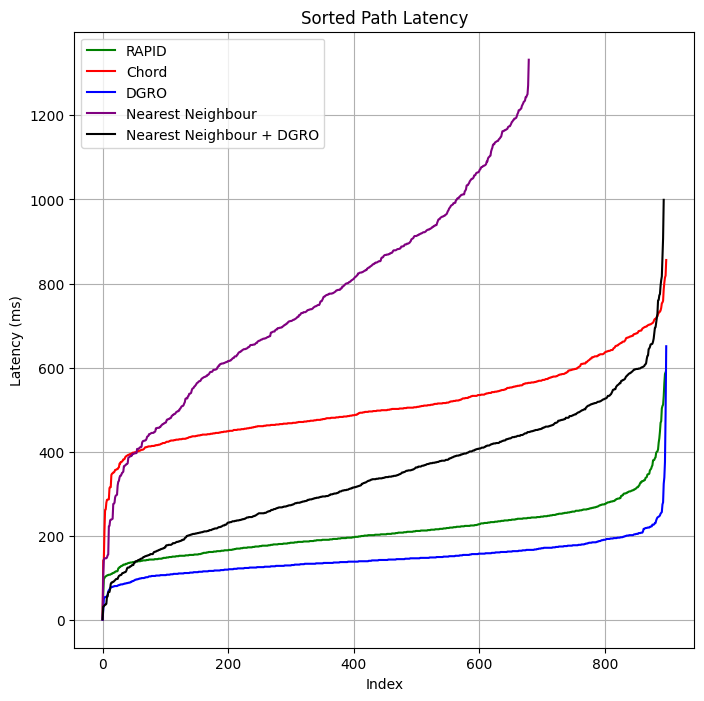

In [10]:
import re
from collections import defaultdict
# import torch as th

K = 8
N = 100
latencies = [[], [], [], [], []]
pattern = re.compile(r'Server receives PHASE2BMESSAGE: (\d+), Endpoint: hostname: "(.*?)"\nport: (\d+)')
pattern_start = re.compile(r'Broadcast Start at (\d+), Endpoint: hostname: "(.*?)"\nport: (\d+)')
filename = [
			'N=1000_random.txt',
			'N=1000_random1.txt',
            'N=1000_6DGRO.txt',
            'N=1000_NN.txt',
            'N=1000_NN+1DGRO.txt'
			
			 ]
	
# for K in [3, 5, 10]:
# for K in [3]:
	# filename = [f"test_data/N={N}_1/random_K={K}.txt", f"test_data/N={N}_1/1shortest_K={K}.txt"]
for id in range(len(filename)):
	with open(filename[id]) as f:
		lines = f.readlines()
		lineSize = len(lines)
		# lines = f.
		
	baseport = -1
	time_by_endpoint = defaultdict(list)
    # Regular expression to extract time and endpoint information
	for i, line in enumerate(lines):
		if 'Borderline' in line or i == lineSize - 1:
			if baseport != -1:
				for endpoint, times in time_by_endpoint.items():
					# if int(endpoint.split(':')[-1]) == baseport:
					# 	continue
					# print(endpoint, times)
					latency = times[0] - start_time
					if endpoint.split(':')[0] == "10.135.2.2":
						latency += 900
						continue
					latencies[id].append(latency)
					# if latency < 0:
					# 	print(filename[id], endpoint, baseport, latency)
					# 	print(times)
                    # 	print(time_by_endpoint[f'127.0.0.7:{baseport}'])
						# assert 0
			if i == lineSize - 1:
				break
			# baseport = int(line.split(' ')[-1][:-1])
			baseport = -1
			time_by_endpoint = defaultdict(list)

		# Extract matches and organize by endpoint
		match = re.match(pattern, line + lines[i + 1])
		if match:
			time, hostname, port = match.groups()
			endpoint = f"{hostname}:{port}"
			time_by_endpoint[endpoint].append(int(time))
			# print(endpoint, time)
		match = re.match(pattern_start, line + lines[i + 1])
		if match:
			start_time, hostname, port = match.groups()
			start_time = int(start_time)
			baseport = int(port)
			print(start_time, hostname, port)
            # print(start_time, hostname, port)
            # print(start_time, hostname, port)
			# endpoint = f"{hostname}:{port}"
			# time_by_endpoint[endpoint].append(int(time))
		
        

import matplotlib.pyplot as plt

# Plot the sorted list
fig, ax = plt.subplots(ncols=1, figsize=(8, 8))
labels = [
    'RAPID', 
		  'Chord',
		    'DGRO',
			  'Nearest Neighbour', 
			  'Nearest Neighbour + DGRO'
			  ]
colors = ['g', 'r', 'b', 'purple', 'k']
linestyles = ['-', '--', '-.']
cnt = 0
# for k in [3, 5, 10]:
for k in [8]:
	for i in range(len(filename)):
		# print(len(latencies[i]))
		path_latency_sorted = sorted(latencies[i])
		# print(path_latency_sorted[:5])
		print(labels[i], path_latency_sorted[-10:])
		# print(path_latency_sorted[:5], path_latency_sorted[-5:])
		ax.plot(path_latency_sorted, linestyle=linestyles[0], 
		  # label=labels[i]+f'_FanOut={k}_N={N}',
		  label=labels[i],
		#   label=filename[i],
		    color=colors[i])
		# cnt += 1
ax.set_title('Sorted Path Latency')
ax.set_xlabel('Index')
ax.set_ylabel('Latency (ms)')
ax.legend()
ax.grid(True)
# plt.show()
fig.savefig(f'N={N}_k={K}.png')